In [2]:
from climb_conversion import ClimbsFeatureArray
from unet_diffusion import ClimbDDPM, Noiser, DDPMTrainer
from diffusion_utils import test_single_batch, moving_average
import seaborn as sns


cfa = ClimbsFeatureArray()
climbs = cfa.get_features(limit=1000)

Initializing ClimbsFeatureArray...
ClimbsFeatureArray initialized! 92651 unique climbs added!
Hold feature vector: 7-dim ['x', 'y', 'pull_x', 'pull_y', 'is_foot', 'pinch', 'flat']


Begining Training. 100 Epochs. 31 Batches. Model Params: 694412


100%|██████████| 100/100 [06:12<00:00,  3.73s/it, Epoch: 99, Batch Loss: 0.08, Improvement: -0.00, Min Loss: 0.0728579585350329, Batches:31]


KeyError: 'y'

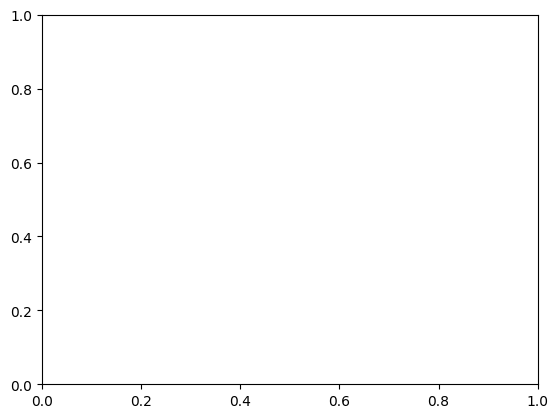

In [3]:
ddpm = ClimbDDPM(Noiser(64, 2, sinusoidal=True))
trainer = DDPMTrainer(ddpm, climbs)
model, losses = trainer.train(100, save_path = "data/weights/new_unet_diff.pth")

<Axes: >

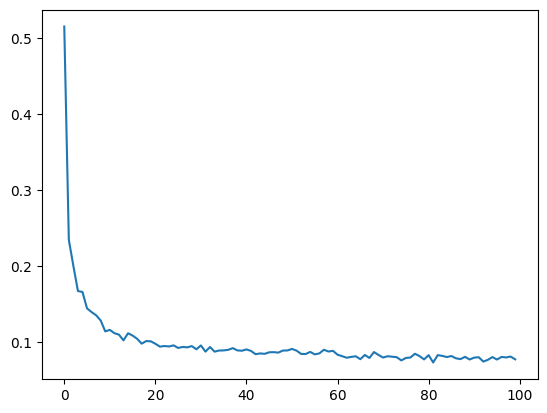

In [4]:
sns.lineplot(y=losses, x=list(range(100)))